In this notebook, we consider the results for the mean reverting process with OU noise.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import numpy as np
import torch
import os
import time
from joblib import Parallel, delayed
from matplotlib.ticker import FixedLocator

import gaussian_crossings.formula as formula
import gaussian_crossings.process as process

# Configure matplotlib for LaTeX rendering
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{amsfonts}" 
})

In [2]:
crossing_type = "upcrossing"  
# crossing_type = "downcrossing"
# crossing_type = "crossing"
ModelClass = formula.GaussianUpCrossingsDimless

mean_rate_method = f"{crossing_type}_mean_rate"
fano_method = f"{crossing_type}_fano_factor_CLT"

In [3]:
if crossing_type == "downcrossing":
    fano_label = r'$\mathrm{F}^\downarrow$'
    mean_label = r'$\mathbb{E}\left[N^\downarrow_u(T)\right]/ \,T$'
    variance_label = r'Var$\left[N^\downarrow_u(T)\right]/ \,T$'
elif crossing_type == "upcrossing":
    fano_label = r'$\mathrm{F}^\uparrow$'
    mean_label = r'$\mathbb{E}\left[N^\uparrow_u(T)\right]/ \, T$'
    variance_label = r'Var$\left[N^\uparrow_u(T)\right]/ \, T$'
else:
    fano_label = r'$\mathrm{F}$'
    mean_label = r'$\mathbb{E}\left[N_u(T)\right]/ \, T$'
    variance_label = r'Var$\left[N_u(T)\right]/ \, T$'

In [4]:
# Set simulation parameters.
T = 100.0    # Total simulation time (e.g., 10 time units)
tau_f = 0.003   # Correlation decay parameter, 3ms
sigma = 1.0 # Standard deviation (amplitude) of the process

In [5]:
num_points_kappa = 250
kappa = torch.linspace(0.01, 0.4, num_points_kappa)

num_points_psi = 250
psi = torch.linspace(0.0, 1.5, num_points_psi)

mean_rates = torch.zeros(num_points_kappa, num_points_psi)
fano_factors = torch.zeros(num_points_kappa, num_points_psi)

In [6]:
def compute_point_ou_noise(i, j, current_kappa, current_psi, sigma, tau_f, 
                          ModelClass, r_func, mean_rate_method, fano_method):
    """Calculate mean rate and Fano factor for a single parameter combination for OU noise."""
    try:
        # Ensure current_kappa is a standard Python float
        kappa_val = current_kappa.item() if isinstance(current_kappa, torch.Tensor) else current_kappa

        # Calculate parameters
        u = current_psi * sigma
        
        # Ensure kappa_val is not zero before division
        if kappa_val == 0:
            print(f"Warning: Skipping calculation for kappa=0 at i={i}, j={j}")
            return i, j, float('nan'), float('nan')
            
        tau_e = tau_f / kappa_val

        # Instantiate the crossing model and compute results
        model = ModelClass(r_func=r_func, u=u, tau=tau_e, kappa=kappa_val, sigma=sigma)
        mr = getattr(model, mean_rate_method)()
        ff = getattr(model, fano_method)(epsilon_left=1e-5, epsilon_right=1e-5)

        return i, j, mr, ff
        
    except Exception as e:
        print(f"Error in worker for i={i}, j={j} (kappa={current_kappa}, psi={current_psi}): {e}")
        return i, j, float('nan'), float('nan')


# Prepare parallel computation tasks
tasks = [(i, j, kappa[i], psi[j]) for i in range(num_points_kappa) for j in range(num_points_psi)]


print(f"Starting parallel computation for {len(tasks)} points...")
start_time = time.time() 

# Execute in parallel
results = Parallel(n_jobs=-1, backend='loky', verbose=1)(
    delayed(compute_point_ou_noise)(
        task[0], task[1], task[2], task[3], 
        sigma, tau_f, ModelClass, process.r_OU_noise, mean_rate_method, fano_method 
    ) for task in tasks
)

end_time = time.time() 
print(f"Parallel computation finished in {end_time - start_time:.2f} seconds.")


for res in results:
    if res is not None: 
        i, j, mr, ff = res
        mean_rates[i, j] = mr
        fano_factors[i, j] = ff
    else:
        print("Warning: A worker task returned None.")

# find the variance
variance = fano_factors * mean_rates

Starting parallel computation for 62500 points...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 4368 tasks      | elapsed:   13.0s
[Parallel(n_jobs=-1)]: Done 12368 tasks      | elapsed:   26.5s
[Parallel(n_jobs=-1)]: Done 23568 tasks      | elapsed:   53.2s
[Parallel(n_jobs=-1)]: Done 37968 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 55568 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 62500 out of 62500 | elapsed:  2.2min finished


Parallel computation finished in 133.60 seconds.


In [7]:
# for i in range(num_points_kappa):
#     for j in range(num_points_psi):
#         # u is given by psi[j]*sigma, and tau_e depends on kappa[i]
#         u = psi[j] * sigma
#         tau_e = tau_f / kappa[i]
#         model = ModelClass(r_func=process.r_OU_noise, u=u, tau=tau_e, kappa=kappa[i], sigma=sigma)
#         mean_rates[i, j] = getattr(model, mean_rate_method)()
#         fano_factors[i, j] = getattr(model, fano_method)(epsilon_left=1e-5, epsilon_right=1e-5)

In [8]:
# Plotting configuration
axis_label_fontsize = 30
title_fontsize = 28
tick_label_fontsize = 24
num_x_ticks = 6
num_y_ticks = 5
tick_line_width = 2.0
spine_line_width = 2.0

# Colormaps
cmap_mean = 'inferno'
cmap_variance = 'inferno'
cmap_diverging = 'PRGn'
cmap_below_1 = 'Blues_r'
cmap_above_1 = 'Reds'

In [9]:
# Fano Factor Colormap Logic
fano_min = fano_factors.min().item()
fano_max = fano_factors.max().item()
spans_one = (fano_min < 1.0) and (fano_max > 1.0)

fano_log = torch.log10(fano_factors)
fano_log_np = fano_log.cpu().numpy()
log_min = fano_log_np.min()
log_max = fano_log_np.max()

# Select colormap and normalization based on range
if spans_one:
    print("Info: Fano factor spans 1. Using custom asymmetric diverging colormap.")
    p_val = (0 - log_min) / (log_max - log_min) if (log_max - log_min) != 0 else 0.5
    p_val = np.clip(p_val, 1e-6, 1.0 - 1e-6)

    base_cmap_obj = plt.get_cmap(cmap_diverging)
    segmented_colors = [
        (0.0, base_cmap_obj(0.0)),    # Color at the start
        (p_val, base_cmap_obj(0.5)),  # Neutral color
        (1.0, base_cmap_obj(1.0))     # Color at the end
    ]
    
    cmap_fano = mcolors.LinearSegmentedColormap.from_list("custom_fano_cmap", segmented_colors)
    norm_fano = mcolors.Normalize(vmin=log_min, vmax=log_max)
else:
    if fano_max <= 1.0:
        print("Info: Max Fano factor <= 1. Using sequential colormap (below).")
        cmap_fano = cmap_below_1
    else:
        print("Info: Min Fano factor >= 1. Using sequential colormap (above).")
        cmap_fano = cmap_above_1
    norm_fano = mcolors.Normalize(vmin=log_min, vmax=log_max)


Info: Fano factor spans 1. Using custom asymmetric diverging colormap.


Saving figures to: ../../figures/OU_noise/phase_diagram_upcrossing


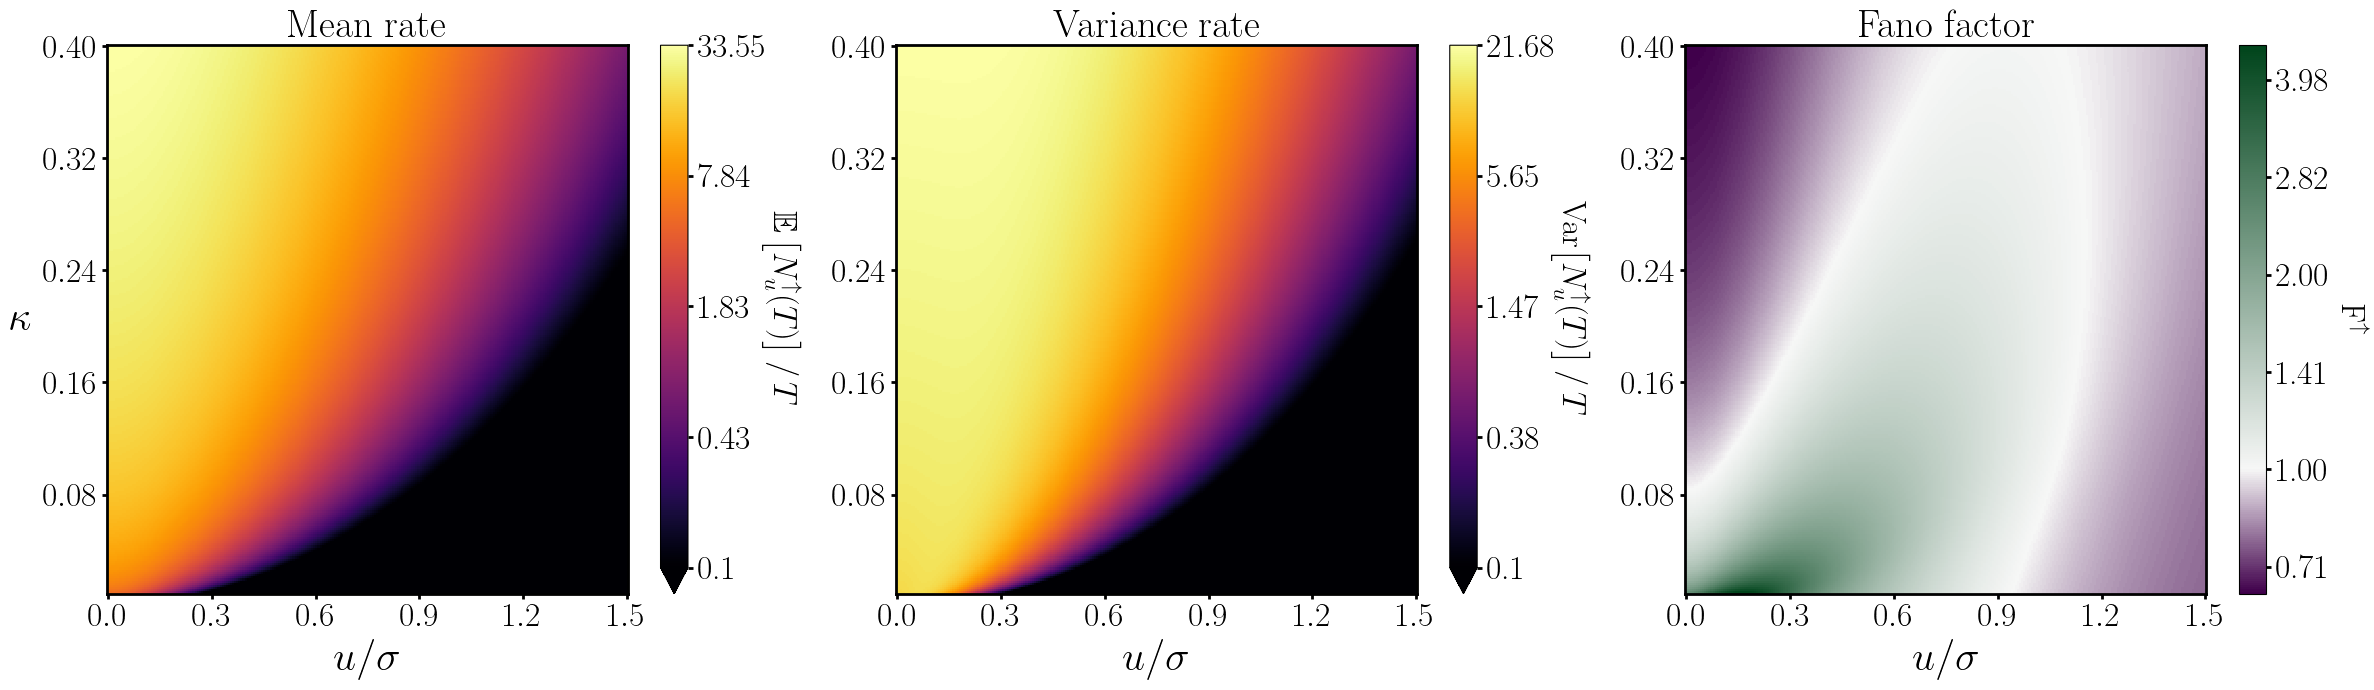

In [14]:
# Create the figure and subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

def format_colorbar_ticks(vals):
    """Format colorbar tick labels, removing trailing zeros."""
    return [f"{v:.2f}".rstrip("0").rstrip(".") for v in vals]

# Left subplot: Mean Rates
epsilon = 0.1
adjusted_mean_rates = torch.clip(mean_rates, epsilon, None)
log_norm = mcolors.LogNorm(vmin=epsilon, vmax=adjusted_mean_rates.max())

pc0 = axes[0].pcolormesh(psi, kappa, adjusted_mean_rates, shading='auto',
                         cmap=cmap_mean, norm=log_norm)
cbar0 = fig.colorbar(pc0, ax=axes[0], extend='min')
cbar0.set_label(mean_label, fontsize=tick_label_fontsize, rotation=270, labelpad=25)
cbar0.ax.tick_params(labelsize=tick_label_fontsize, width=tick_line_width)

tick_vals = np.geomspace(epsilon, adjusted_mean_rates.max().item(), 5)
cbar0.set_ticks(tick_vals)
cbar0.ax.minorticks_off()
cbar0.set_ticklabels(format_colorbar_ticks(tick_vals))

axes[0].set_xlabel(r'$u/\sigma$', fontsize=axis_label_fontsize)
axes[0].set_ylabel(r'$\kappa$', fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=15)
axes[0].set_title('Mean rate', fontsize=title_fontsize)
axes[0].xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks))
axes[0].yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks))
axes[0].tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)

for spine in axes[0].spines.values():
    spine.set_linewidth(spine_line_width)

# Middle subplot: Variance
adjusted_variance = torch.clip(variance, epsilon, None)
log_norm_var = mcolors.LogNorm(vmin=epsilon, vmax=adjusted_variance.max())

pc1 = axes[1].pcolormesh(psi, kappa, adjusted_variance, shading='auto',
                         cmap=cmap_variance, norm=log_norm_var)
cbar1 = fig.colorbar(pc1, ax=axes[1], extend='min')
cbar1.set_label(variance_label, fontsize=tick_label_fontsize, rotation=270, labelpad=25)
cbar1.ax.tick_params(labelsize=tick_label_fontsize, width=tick_line_width)

tick_vals = np.geomspace(epsilon, adjusted_variance.max().item(), 5)
cbar1.set_ticks(tick_vals)
cbar1.ax.minorticks_off()
cbar1.set_ticklabels(format_colorbar_ticks(tick_vals))

axes[1].set_xlabel(r'$u/\sigma$', fontsize=axis_label_fontsize)
axes[1].set_title('Variance rate', fontsize=title_fontsize)
axes[1].xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks))
axes[1].yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks))
axes[1].tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)

for spine in axes[1].spines.values():
    spine.set_linewidth(spine_line_width)

# Right subplot: Fano Factors
pc2 = axes[2].pcolormesh(psi, kappa, fano_log_np, shading='auto',
                         cmap=cmap_fano, norm=norm_fano)
cbar2 = fig.colorbar(pc2, ax=axes[2])
cbar2.set_label(fano_label, fontsize=tick_label_fontsize, rotation=270, labelpad=25)
cbar2.ax.tick_params(labelsize=tick_label_fontsize, width=tick_line_width)

tick_locs_fano = mticker.MaxNLocator(nbins=6).tick_values(log_min, log_max)
cbar2.locator = FixedLocator(tick_locs_fano)
cbar2.formatter = mticker.FuncFormatter(lambda x, pos: f"{10**x:.2f}")
cbar2.update_ticks()

axes[2].set_xlabel(r'$u/\sigma$', fontsize=axis_label_fontsize)
axes[2].set_title("Fano factor", fontsize=title_fontsize)
axes[2].xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks))
axes[2].yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks))
axes[2].tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)

for spine in axes[2].spines.values():
    spine.set_linewidth(spine_line_width)

plt.tight_layout()

# Save the figure
folder_loc = '../../figures/OU_noise/'
os.makedirs(folder_loc, exist_ok=True)
file_name = f'phase_diagram_{crossing_type}'
file_save_path = os.path.join(folder_loc, file_name)

print(f"Saving figures to: {file_save_path}")
# Uncomment to save:
plt.savefig(f'{file_save_path}.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.eps', format='eps', bbox_inches='tight', dpi=300)

plt.show()
